# Exercise 5

In [428]:
import numpy as np
from scipy.stats import t
import scipy.stats as ss
import time
import math
import matplotlib.pyplot as plt

In [ ]:
gt = np.exp(1)-1
print(f'Ground truth: {gt}')

Ground truth: 1.718281828459045


### Part 1

In [393]:
seed = 30
rng = np.random.default_rng(seed)

t1 = time.time()
n = 100
U = rng.uniform(size=n)
X = np.exp(U)
E = np.mean(X)
print(f'Time: {time.time() - t1}')

print(f'Estimated value: {E}')

print(f'Difference: {np.abs(E-gt)}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([(X[i]-E)**2 for i in range(n)])))
conf1 = tdist[0] * S / np.sqrt(n) + E
conf2 = tdist[1] * S / np.sqrt(n) + E
print(f'Confidence interval: {(conf1, conf2)}')

Time: 0.0
Estimated value: 1.7207379667184908
Difference: 0.0024561382594456838
Confidence interval: (1.625743021661111, 1.8157329117758705)


### Part 2

In [394]:
seed = 30
rng = np.random.default_rng(seed)

t1 = time.time()
n = 100
U = rng.uniform(size=n)
Y = (np.exp(U)+np.exp(1-U))/2
E = np.mean(Y)
print(f'Time: {time.time() - t1}')

print(f'Estimated value: {E}')

print(f'Difference: {np.abs(E-gt)}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([(Y[i]-E)**2 for i in range(n)])))
conf1 = tdist[0] * S / np.sqrt(n) + E
conf2 = tdist[1] * S / np.sqrt(n) + E
print(f'Confidence interval: {(conf1, conf2)}')

Time: 0.0
Estimated value: 1.7079341193220712
Difference: 0.010347709136973915
Confidence interval: (1.6961008390728838, 1.7197673995712586)


### Part 3

In [395]:
seed = 30
rng = np.random.default_rng(seed)

t1 = time.time()
n = 100
U = rng.uniform(size=n)
X = np.exp(U)
c = -1.69
Y = X + c*(U-1/2)
E = np.mean(Y)
print(f'Time: {time.time() - t1}')

print(f'Estimated value: {E}')

print(f'Difference: {np.abs(E-gt)}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([(Y[i]-E)**2 for i in range(n)])))
conf1 = tdist[0] * S / np.sqrt(n) + E
conf2 = tdist[1] * S / np.sqrt(n) + E
print(f'Confidence interval: {(conf1, conf2)}')

Time: 0.0018246173858642578
Estimated value: 1.7098575104974887
Difference: 0.008424317961556405
Confidence interval: (1.6977001336436615, 1.722014887351316)


### Part 4

In [396]:
seed = 30
rng = np.random.default_rng(seed)

t1 = time.time()
n = 100
U = np.zeros(n)
for i in range(10):
    U[10*i:10*(i+1)] = rng.uniform(low=i*0.1, high=(i+1)*0.1, size=10)
Y = np.exp(U)
E = np.mean(Y)
print(f'Time: {time.time() - t1}')

print(f'Estimated value: {E}')

print(f'Difference: {np.abs(E-gt)}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([(Y[i]-E)**2 for i in range(n)])))
conf1 = tdist[0] * S / np.sqrt(n) + E
conf2 = tdist[1] * S / np.sqrt(n) + E
print(f'Confidence interval: {(conf1, conf2)}')

Time: 0.0011990070343017578
Estimated value: 1.7194217484513832
Difference: 0.0011399199923380898
Confidence interval: (1.6214430955099894, 1.817400401392777)


### Part 5

In [397]:
def analytical_blocked(m, mean_service_time, mean_arrival):
    A = mean_service_time*mean_arrival
    B = (A**m)/(math.factorial(m))
    temp = 0
    for i in range(m+1):
        temp += (A**i)/(math.factorial(i))
    return B/temp

In [398]:
def blocking_system_poisson(temp, m, mean_service_time, max_customers, rng):
    servers = np.zeros(m)
    customers = 0
    t = 0
    blocked_customers = 0

    while(customers < max_customers):
        arrival_time = temp[customers]
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        mask = servers == 0
        if (np.sum(mask) == 0):
            blocked_customers += 1
        else:
            for i in range(m):
                if (servers[i] == 0):
                    servers[i] = rng.exponential(mean_service_time)
                    break
        
        customers += 1
    
    return blocked_customers/max_customers

In [399]:
seed = 30
rng = np.random.default_rng(seed)

mean_arrival = 1
print(f'Arrival process as a Poisson process with mean={mean_arrival}')

theoretical_rate = analytical_blocked(m=10, mean_service_time=8, mean_arrival=1)

print(f'Theoretical rate: {theoretical_rate}')

n = 10
tests = np.zeros(n)
control_variates = np.zeros(n)
for i in range(n):
    temp = rng.exponential(mean_arrival, size=10_000)
    control_variates[i] = np.mean(temp)
    tests[i] = blocking_system_poisson(temp=temp, m=10, mean_service_time=8, max_customers=10_000, rng=rng)

c = -np.cov(tests, control_variates)[0,1]/(np.var(control_variates))
Y = tests + c*(control_variates-1)

mean = np.mean(Y)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([(Y[i]-mean)**2 for i in range(n)])))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')
print(f'Confidence interval width: {conf2 - conf1}')

Arrival process as a Poisson process with mean=1
Theoretical rate: 0.12166106425295149
Estimated rate: 0.12327588900842652
Confidence interval: (0.11984411127688116, 0.12670766673997189)
Confidence interval width: 0.006863555463090726


### Part 7

In [400]:
seed = 30
rng = np.random.default_rng(seed)

a = 2
h = lambda x: x>a

print(f'Ground truth for a={a}: {1-ss.norm.cdf(a, loc=0, scale=1)}')

n = 100
X = rng.normal(loc=0, scale=1, size=n)
crude = np.mean(h(X))
print(f'Crude monte carlo with n={100} samples: {crude}')

sigma = 1
Y = rng.normal(loc=a, scale=sigma**2, size=n)
importance = np.mean(h(Y)*ss.norm.pdf(Y, loc=0, scale=1)/ss.norm.pdf(Y, loc=a, scale=sigma**2))
print(f'Importance sampling with n={100} samples: {importance}')

Ground truth for a=2: 0.02275013194817921
Crude monte carlo with n=100 samples: 0.03
Importance sampling with n=100 samples: 0.024792542897022696


### Part 8

Ground truth: 1.718281828459045


(0.0, 5.0)

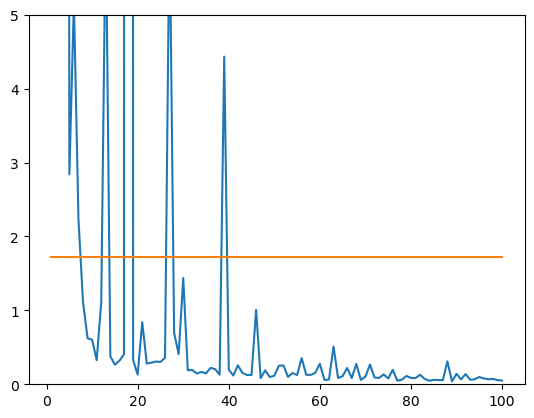

In [437]:
gt = np.exp(1)-1
print(f'Ground truth: {gt}')

seed = 30
rng = np.random.default_rng(seed)

lams = np.linspace(1,100,100)

importance = np.zeros(100)

for i in range(100):
    lam = lams[i]
    h = lambda x: np.exp(x)
    g = lambda x: lam*np.exp(-lam*x)
    f = lambda x: 1

    n = 100
    Y = rng.exponential(scale=1/lam, size=n)
    importance[i] = np.mean(h(Y)*f(Y)/g(Y))

plt.plot(lams, importance)
plt.plot(lams, [gt for i in range(100)])
plt.ylim([0,5])